# QR-DQN

To capture the full distribution of rewards rather than just the expected value, we implemented Distributional Reinforcement Learning with Quantile Regression (QR-DQN) (Dabney et al., 2018). QR-DQN predicts a set of quantiles for the return distribution. This approach often leads to much more robust learning and provides the agent with a richer signal from the environment, which is evident in its superior performance in our evaluation.

## Imports

In [25]:
import random

import numpy as np
import torch
import torch.nn as nn
import pyspiel

import argparse
import json
import os
import re
from collections import namedtuple

from tqdm.auto import tqdm
import torch.optim as optim


## Helper Functions

In [26]:
# A compact transition record that keeps the replay buffer easy to sample and unpack.
Transition = namedtuple(
    "Transition",
    ["obs", "action", "reward", "next_obs", "done", "legal_mask", "next_legal_mask"],
)


def extract_obs(state, player_id=0):
    """Return a flat float32 observation vector for the player."""
    for fn_name, args in [
        ("observation_tensor", (player_id,)),
        ("observation_tensor", tuple()),
        ("information_state_tensor", (player_id,)),
        ("information_state_tensor", tuple()),
    ]:
        fn = getattr(state, fn_name, None)
        if fn is None:
            continue
        try:
            obs = fn(*args)
            return np.asarray(obs, dtype=np.float32).reshape(-1)
        except TypeError:
            pass
    raise RuntimeError("Could not extract an observation tensor from state.")


def legal_actions(state, player_id=0):
    """Return legal actions for the current player state."""
    try:
        return list(state.legal_actions(player_id))
    except TypeError:
        return list(state.legal_actions())


def sample_chance_action(state, rng):
    outcomes = state.chance_outcomes()
    actions, probs = zip(*outcomes)
    idx = rng.choice(len(actions), p=np.asarray(probs, dtype=np.float64))
    return actions[idx]


def auto_resolve_chance_nodes(state, rng):
    """Advance chance nodes until the environment is back at a player decision."""
    while state.is_chance_node() and not state.is_terminal():
        action = sample_chance_action(state, rng)
        state.apply_action(action)
    return state


def state_return(state, player_id=0):
    values = state.returns()
    return float(values[player_id]) if len(values) > player_id else 0.0


def state_reward(state, player_id=0):
    values = state.rewards()
    return float(values[player_id]) if len(values) > player_id else 0.0


def parse_board_numbers(state):
    """Best-effort text parser for showing the board as a 4x4 integer array."""
    text = str(state)
    numbers = [int(x) for x in re.findall(r"\d+", text)]
    if len(numbers) >= 16:
        numbers = numbers[-16:]
        return np.array(numbers, dtype=np.int64).reshape(4, 4)
    return None


def epsilon_by_step(
    step: int,
    eps_start: float = 1.0,
    eps_end: float = 0.05,
    eps_decay_steps: int = 20_000,
):
    """Linear epsilon schedule from eps_start to eps_end over eps_decay_steps."""
    decay_steps = max(1, int(eps_decay_steps))
    frac = min(1.0, step / decay_steps)
    return eps_start + frac * (eps_end - eps_start)


def make_legal_mask(num_actions: int, legal_actions_list: list):
    mask = np.zeros(num_actions, dtype=np.float32)
    mask[legal_actions_list] = 1.0
    return mask


@torch.no_grad()
def masked_greedy_action(
    q_net, obs, legal_actions_list, num_actions, epsilon=0.0, device=None
):
    if random.random() < epsilon:
        return random.choice(legal_actions_list)

    obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
    q_values = q_net(obs_t).squeeze(0)

    legal_mask = torch.zeros(num_actions, dtype=torch.bool, device=device)
    legal_mask[legal_actions_list] = True
    q_masked = q_values.masked_fill(~legal_mask, -1e9)
    return int(torch.argmax(q_masked).item())


def evaluate_multi_seed(
    q_net,
    env_class,
    num_eval_seeds=10,
    num_actions=4,
    max_steps_per_episode=5_000,
    device=None,
    seed_offset=5000,
):
    """Evaluate the greedy policy over multiple random seeds."""
    if device is None:
        device = torch.device("cpu")

    eval_rollout_seed_ids = []
    eval_rollout_episode_ids = []
    eval_rollout_step_ids = []
    eval_rollout_states = []
    eval_rollout_next_states = []
    eval_rollout_actions = []
    eval_rollout_rewards = []
    eval_rollout_dones = []
    eval_rollout_legal_masks = []
    eval_rollout_illegal_action_attempt_flags = []
    eval_rollout_episode_returns = []
    eval_rollout_episode_lengths = []
    eval_rollout_episode_illegal_action_attempts = []

    multi_seed_returns = []
    multi_seed_lengths = []
    multi_seed_max_tiles = []

    for seed_idx in range(num_eval_seeds):
        eval_seed = seed_offset + seed_idx
        eval_env = env_class(seed=eval_seed)
        obs = eval_env.reset(seed=eval_seed)
        done = False
        ret = 0.0
        steps = 0
        max_tile = 0
        illegal_attempts = 0

        eval_rollout_seed_ids.append(eval_seed)

        while not done and steps < max_steps_per_episode:
            if obs is not None and len(obs) > 0:
                max_tile = max(max_tile, int(np.max(obs)))

            legal = eval_env.legal_actions()
            legal_mask = make_legal_mask(num_actions, legal)
            with torch.no_grad():
                obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(
                    0
                )
                q_values = q_net(obs_t).squeeze(0)
            raw_greedy_action = int(torch.argmax(q_values).item())
            illegal_action_attempt = raw_greedy_action not in legal
            if illegal_action_attempt:
                illegal_attempts += 1

            action = masked_greedy_action(
                q_net=q_net,
                obs=obs,
                legal_actions_list=legal,
                num_actions=num_actions,
                epsilon=0.0,
                device=device,
            )
            next_obs, reward, done, info = eval_env.step(action)

            eval_rollout_episode_ids.append(seed_idx)
            eval_rollout_step_ids.append(steps)
            eval_rollout_states.append(np.asarray(obs, dtype=np.float32))
            eval_rollout_next_states.append(np.asarray(next_obs, dtype=np.float32))
            eval_rollout_actions.append(int(action))
            eval_rollout_rewards.append(float(reward))
            eval_rollout_dones.append(bool(done))
            eval_rollout_legal_masks.append(legal_mask.astype(np.bool_))
            eval_rollout_illegal_action_attempt_flags.append(
                bool(illegal_action_attempt)
            )

            obs = next_obs
            ret += reward
            steps += 1

        multi_seed_returns.append(ret)
        multi_seed_lengths.append(steps)
        multi_seed_max_tiles.append(max_tile)
        eval_rollout_episode_returns.append(ret)
        eval_rollout_episode_lengths.append(steps)
        eval_rollout_episode_illegal_action_attempts.append(illegal_attempts)

    summary = {
        "avg_return": float(np.mean(multi_seed_returns)),
        "std_return": float(np.std(multi_seed_returns)),
        "min_return": float(np.min(multi_seed_returns)),
        "max_return": float(np.max(multi_seed_returns)),
        "avg_length": float(np.mean(multi_seed_lengths)),
        "avg_max_tile": float(np.mean(multi_seed_max_tiles)),
        "avg_illegal_action_attempts": float(
            np.mean(eval_rollout_episode_illegal_action_attempts)
        ),
        "total_illegal_action_attempts": int(
            np.sum(eval_rollout_episode_illegal_action_attempts)
        ),
    }

    return {
        "seed_ids": np.asarray(eval_rollout_seed_ids, dtype=np.int64),
        "episode_ids": np.asarray(eval_rollout_episode_ids, dtype=np.int64),
        "step_ids": np.asarray(eval_rollout_step_ids, dtype=np.int64),
        "states": np.stack(eval_rollout_states).astype(np.float32),
        "next_states": np.stack(eval_rollout_next_states).astype(np.float32),
        "actions": np.asarray(eval_rollout_actions, dtype=np.int64),
        "rewards": np.asarray(eval_rollout_rewards, dtype=np.float32),
        "dones": np.asarray(eval_rollout_dones, dtype=np.bool_),
        "legal_masks": np.stack(eval_rollout_legal_masks).astype(np.bool_),
        "illegal_action_attempt_flags": np.asarray(
            eval_rollout_illegal_action_attempt_flags, dtype=np.bool_
        ),
        "episode_returns": np.asarray(eval_rollout_episode_returns, dtype=np.float32),
        "episode_lengths": np.asarray(eval_rollout_episode_lengths, dtype=np.int64),
        "episode_illegal_action_attempts": np.asarray(
            eval_rollout_episode_illegal_action_attempts, dtype=np.int64
        ),
        "max_tiles": np.asarray(multi_seed_max_tiles, dtype=np.int64),
        "summary": summary,
    }


def save_eval_results(
    eval_data,
    output_dir,
    num_actions,
    obs_dim,
    source_notebook="QR-DQN",
    checkpoint_file="dqn.pt",
):
    """Save evaluation results to NPZ and metadata JSON."""
    os.makedirs(output_dir, exist_ok=True)

    npz_path = os.path.join(output_dir, "eval_rollout.npz")
    np.savez_compressed(
        npz_path,
        seed_ids=eval_data["seed_ids"],
        episode_ids=eval_data["episode_ids"],
        step_ids=eval_data["step_ids"],
        states=eval_data["states"],
        next_states=eval_data["next_states"],
        actions=eval_data["actions"],
        rewards=eval_data["rewards"],
        dones=eval_data["dones"],
        legal_masks=eval_data["legal_masks"],
        illegal_action_attempt_flags=eval_data["illegal_action_attempt_flags"],
        episode_returns=eval_data["episode_returns"],
        episode_lengths=eval_data["episode_lengths"],
        episode_illegal_action_attempts=eval_data["episode_illegal_action_attempts"],
        max_tiles=eval_data["max_tiles"],
        num_actions=np.int64(num_actions),
        obs_dim=np.int64(obs_dim),
    )

    eval_meta = {
        "schema_version": 1,
        "game": "2048",
        "library": "OpenSpiel",
        "source_notebook": source_notebook,
        "checkpoint_file": checkpoint_file,
        "rollout_file": "eval_rollout.npz",
        "num_eval_seeds": int(len(eval_data["seed_ids"])),
        "seed_ids": [int(s) for s in eval_data["seed_ids"]],
        "obs_dim": int(obs_dim),
        "num_actions": int(num_actions),
        "action_order": "OpenSpiel action indices 0..num_actions-1",
        "state_encoding": "flat observation tensor from the embedded environment wrapper",
        "state_storage": "pre-action and post-action observations in eval_rollout.npz",
        "episode_boundaries": "episode_ids and step_ids define episode grouping",
        "summary": eval_data["summary"],
    }

    json_path = os.path.join(output_dir, "eval_meta.json")
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(eval_meta, f, indent=2)

    return npz_path, json_path


def evaluate_policy(args, q_policy, num_actions, device):
    """Run multi-seed evaluation and print summary metrics."""
    print_summary = bool(getattr(args, "print_eval_summary", True))
    eval_data = evaluate_multi_seed(
        q_net=q_policy,
        env_class=OpenSpiel2048Env,
        num_eval_seeds=args.num_eval_seeds,
        num_actions=num_actions,
        max_steps_per_episode=args.max_steps_per_episode,
        device=device,
        seed_offset=5000,
    )

    summary = eval_data["summary"]
    if print_summary:
        print(f"Results over {args.num_eval_seeds} seeds:")
        print(
            f"  Average return:           {summary['avg_return']:.1f} +/- {summary['std_return']:.1f}"
        )
        print(f"  Average episode length:   {summary['avg_length']:.1f}")
        print(f"  Average max tile:         {summary['avg_max_tile']:.1f}")
        print(
            f"  Average illegal attempts: {summary['avg_illegal_action_attempts']:.1f}"
        )
        print(f"  Total illegal attempts:   {summary['total_illegal_action_attempts']}")

    return eval_data


def save_artifacts(args, q_net, target_net, obs_dim, num_actions, eval_data):
    """Save checkpoint and evaluation files only when output_dir is explicitly provided."""
    log_save = bool(getattr(args, "log_save", True))
    if not args.output_dir:
        if log_save:
            print(
                "Skipping save: pass output_dir to persist checkpoint and evaluation files."
            )
        return

    os.makedirs(args.output_dir, exist_ok=True)
    npz_path, json_path = save_eval_results(
        eval_data=eval_data,
        output_dir=args.output_dir,
        num_actions=num_actions,
        obs_dim=obs_dim,
        source_notebook="QR-DQN",
        checkpoint_file="dqn.pt",
    )
    if log_save:
        print(f"Saved evaluation rollout archive to: {npz_path}")
        print(f"Saved evaluation metadata to: {json_path}")

    checkpoint_path = os.path.join(args.output_dir, "dqn.pt")
    torch.save(
        {
            "model_state_dict": q_net.state_dict(),
            "target_state_dict": target_net.state_dict(),
            "obs_dim": obs_dim,
            "num_actions": num_actions,
            "num_quantiles": q_net.num_quantiles,
        },
        checkpoint_path,
    )
    if log_save:
        print(f"Saved checkpoint to: {checkpoint_path}")

## Light Game Wrapper

In [27]:
class OpenSpiel2048Env:
    def __init__(self, seed=42):
        self.game = pyspiel.load_game("2048")
        self.player_id = 0
        self.num_actions = self.game.num_distinct_actions()
        self.obs_dim = self.game.observation_tensor_size()
        self.rng = np.random.default_rng(seed)
        self.state = None

    def reset(self, seed=None):
        # Re-seed here so evaluation can replay the same trajectory exactly.
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.state = self.game.new_initial_state()
        auto_resolve_chance_nodes(self.state, self.rng)
        return extract_obs(self.state, self.player_id)

    def step(self, action):
        if self.state is None:
            raise RuntimeError("Call reset() before step().")
        if self.state.is_terminal():
            raise RuntimeError("Episode already ended. Call reset().")

        legal = legal_actions(self.state, self.player_id)
        if action not in legal:
            raise ValueError(f"Illegal action {action}. Legal actions: {legal}")

        prev_return = state_return(self.state, self.player_id)
        self.state.apply_action(int(action))
        auto_resolve_chance_nodes(self.state, self.rng)

        next_obs = (
            extract_obs(self.state, self.player_id)
            if not self.state.is_terminal()
            else np.zeros(self.obs_dim, dtype=np.float32)
        )
        new_return = state_return(self.state, self.player_id)
        reward = new_return - prev_return
        done = self.state.is_terminal()
        info = {
            "legal_actions": legal_actions(self.state, self.player_id)
            if not done
            else [],
            "state_return": new_return,
            "state_reward_raw": state_reward(self.state, self.player_id),
            "board": parse_board_numbers(self.state),
            "state_text": str(self.state),
        }
        return next_obs, float(reward), done, info

    def legal_actions(self):
        if self.state is None or self.state.is_terminal():
            return []
        return legal_actions(self.state, self.player_id)

    def render(self):
        if self.state is None:
            print("<env not reset>")
        else:
            print(self.state)


## QuantileQNetwork

In [28]:
class ReplayBuffer:
    def __init__(self, capacity: int):
        from collections import deque

        self.buffer = deque(maxlen=capacity)

    def __len__(self):
        return len(self.buffer)

    def add(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))


class QuantileQNetwork(nn.Module):
    """Feed-forward quantile network for QR-DQN."""

    def __init__(
        self,
        obs_dim: int,
        num_actions: int,
        num_quantiles: int = 51,
        hidden_dim: int = 256,
    ):
        super().__init__()
        self.num_actions = num_actions
        self.num_quantiles = num_quantiles
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_actions * num_quantiles),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Return quantile values with shape [batch, num_actions, num_quantiles]."""
        out = self.net(x)
        return out.view(-1, self.num_actions, self.num_quantiles)

    def q_values(self, x: torch.Tensor) -> torch.Tensor:
        """Return expected Q-values by averaging quantiles over the atom dimension."""
        return self.forward(x).mean(dim=2)


class ExpectedQPolicy(torch.nn.Module):
    """Adapter so the evaluation helpers can consume a quantile network as Q-values."""

    def __init__(self, quantile_net: QuantileQNetwork):
        super().__init__()
        self.quantile_net = quantile_net

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.quantile_net.q_values(x)


@torch.no_grad()
def masked_greedy_quantile_action(
    q_net: QuantileQNetwork,
    obs,
    legal_actions_list,
    num_actions: int,
    epsilon: float,
    device: torch.device,
) -> int:
    if random.random() < epsilon:
        return random.choice(legal_actions_list)

    obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
    q_values = q_net.q_values(obs_t).squeeze(0)

    legal_mask = torch.zeros(num_actions, dtype=torch.bool, device=device)
    legal_mask[legal_actions_list] = True
    q_masked = q_values.masked_fill(~legal_mask, -1e9)
    return int(torch.argmax(q_masked).item())

## Train Helper Functions

This section contains the core learning logic for QR-DQN. The key difference from standard DQN is that we do not predict one scalar value per action. Instead, we predict a **distribution** of returns using multiple quantiles.

- The network outputs `num_quantiles` values per action, not a single Q-value.
- Action selection still uses expected value (mean over quantiles), so policy behavior remains easy to interpret.
- Learning uses **quantile regression Huber loss**, which trains each predicted quantile against the target return distribution.
- Target construction uses a Double-DQN style step (online net selects the next action, target net evaluates it) to reduce overestimation.

In practice, this gives the agent richer supervision than scalar TD learning, especially in noisy or high-variance trajectories, which often improves stability and final policy quality on 2048.

In [29]:
def quantile_huber_loss(pred_quantiles, target_quantiles, taus, kappa):
    """Compute the QR-DQN quantile Huber loss for [batch, num_quantiles] tensors."""
    td_error = target_quantiles.unsqueeze(1) - pred_quantiles.unsqueeze(2)
    abs_error = torch.abs(td_error)
    huber = torch.where(
        abs_error <= kappa,
        0.5 * td_error.pow(2),
        kappa * (abs_error - 0.5 * kappa),
    )
    quantile_weight = torch.abs(taus.view(1, -1, 1) - (td_error.detach() < 0).float())
    return (quantile_weight * huber).mean()


def qr_dqn_update(batch, q_net, target_net, optimizer, gamma, grad_clip, kappa, device):
    # Convert replay batch fields to tensors on the selected device.
    obs = torch.tensor(np.asarray(batch.obs), dtype=torch.float32, device=device)
    actions = torch.tensor(batch.action, dtype=torch.int64, device=device)
    rewards = torch.tensor(batch.reward, dtype=torch.float32, device=device)
    next_obs = torch.tensor(np.asarray(batch.next_obs), dtype=torch.float32, device=device)
    dones = torch.tensor(batch.done, dtype=torch.float32, device=device)
    next_legal_mask = torch.tensor(np.asarray(batch.next_legal_mask), dtype=torch.bool, device=device)

    batch_size = obs.shape[0]
    num_quantiles = q_net.num_quantiles

    # Predict quantiles for all actions, then gather quantiles of the executed action a_t.
    all_quantiles = q_net(obs)
    action_idx = actions.view(batch_size, 1, 1).expand(batch_size, 1, num_quantiles)
    pred_quantiles = all_quantiles.gather(1, action_idx).squeeze(1)

    with torch.no_grad():
        # Double-DQN style target selection:
        # 1) select argmax action using online network expected values,
        # 2) evaluate that selected action with the target network quantiles.
        next_online_q = q_net.q_values(next_obs).masked_fill(~next_legal_mask, -1e9)
        next_actions = torch.argmax(next_online_q, dim=1)

        next_action_idx = next_actions.view(batch_size, 1, 1).expand(batch_size, 1, num_quantiles)
        next_quantiles = target_net(next_obs).gather(1, next_action_idx).squeeze(1)
        next_quantiles = torch.where(dones.unsqueeze(1) > 0.5, torch.zeros_like(next_quantiles), next_quantiles)
        target_quantiles = rewards.unsqueeze(1) + gamma * next_quantiles

    # Midpoint quantile fractions tau_i = (i + 0.5) / N used by QR loss weighting.
    taus = (
        (torch.arange(num_quantiles, dtype=torch.float32, device=device) + 0.5)
        / float(num_quantiles)
    )
    loss = quantile_huber_loss(pred_quantiles, target_quantiles, taus, kappa=kappa)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(q_net.parameters(), grad_clip)
    optimizer.step()

    return float(loss.item())


def greedy_rollout(q_net, env, num_actions, max_steps=5_000, device=None):
    """Run a single greedy rollout and record the transition history."""
    if device is None:
        device = torch.device("cpu")

    obs = env.reset()
    done = False
    episode_return = 0.0
    episode_length = 0
    max_tile = 0
    illegal_action_attempts = 0
    rollout = []

    while not done and episode_length < max_steps:
        if obs is not None and len(obs) > 0:
            max_tile = max(max_tile, int(np.max(obs)))

        legal = env.legal_actions()
        with torch.no_grad():
            obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            q_values = q_net(obs_t).squeeze(0)
        raw_greedy_action = int(torch.argmax(q_values).item())
        illegal_action_attempt = raw_greedy_action not in legal
        if illegal_action_attempt:
            illegal_action_attempts += 1

        action = masked_greedy_action(
            q_net=q_net,
            obs=obs,
            legal_actions_list=legal,
            num_actions=num_actions,
            epsilon=0.0,
            device=device,
        )

        next_obs, reward, done, info = env.step(action)
        rollout.append(
            {
                "action": action,
                "reward": reward,
                "legal_actions": legal,
                "board": info.get("board"),
                "state_text": info.get("state_text"),
                "raw_greedy_action": raw_greedy_action,
                "illegal_action_attempt": bool(illegal_action_attempt),
            }
        )
        obs = next_obs
        episode_return += reward
        episode_length += 1

    return episode_return, episode_length, max_tile, illegal_action_attempts, rollout


TRAINING_INSIGHTS = {
    "eval_episode": [],
    "eval_return": [],
    "eval_length": [],
    "eval_max_tile": [],
    "eval_illegal_action_attempts": [],
    "eval_rollout": [],
}


def train(args, device):
    log_episodes = bool(getattr(args, "log_episodes", True))

    global TRAINING_INSIGHTS
    # Reset tracking at the beginning of each training run.
    TRAINING_INSIGHTS = {
        "eval_episode": [],
        "eval_return": [],
        "eval_length": [],
        "eval_max_tile": [],
        "eval_illegal_action_attempts": [],
        "eval_rollout": [],
    }

    # Seed all RNGs once so training is as reproducible as possible.
    random.seed(args.seed)
    np.random.seed(args.seed)
    torch.manual_seed(args.seed)

    train_env = OpenSpiel2048Env(seed=args.seed)
    obs_dim = train_env.obs_dim
    num_actions = train_env.num_actions

    # QR-DQN uses two quantile networks: online for learning and target for stable bootstrap targets.
    q_net = QuantileQNetwork(obs_dim, num_actions, num_quantiles=args.num_quantiles).to(device)
    target_net = QuantileQNetwork(obs_dim, num_actions, num_quantiles=args.num_quantiles).to(device)
    target_net.load_state_dict(q_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(q_net.parameters(), lr=args.lr)
    replay = ReplayBuffer(args.buffer_size)
    q_policy = ExpectedQPolicy(q_net)

    global_step = 0
    for episode in tqdm(range(1, args.num_episodes + 1), desc="Training"):
        obs = train_env.reset(seed=args.seed + episode)
        done = False
        ep_return = 0.0
        ep_len = 0
        max_tile = 0
        illegal_attempts = 0
        ep_losses = []

        while not done and ep_len < args.max_steps_per_episode:
            # Exploration is controlled by an epsilon schedule over environment steps.
            eps = epsilon_by_step(
                global_step,
                eps_start=args.eps_start,
                eps_end=args.eps_end,
                eps_decay_steps=args.eps_decay_steps,
            )
            legal = train_env.legal_actions()
            legal_mask = make_legal_mask(num_actions, legal)

            if obs is not None and len(obs) > 0:
                max_tile = max(max_tile, int(np.max(obs)))

            with torch.no_grad():
                q_vals = q_net.q_values(torch.tensor(np.asarray([obs]), dtype=torch.float32, device=device))
                q_vals_np = q_vals.cpu().numpy()[0]

            # Action choice uses expected Q (mean over quantiles) but keeps legal-action masking.
            action = masked_greedy_quantile_action(
                q_net=q_net,
                obs=obs,
                legal_actions_list=legal,
                num_actions=num_actions,
                epsilon=eps,
                device=device,
            )

            if eps > 0 and len(legal) < num_actions:
                best_raw_action = int(np.argmax(q_vals_np))
                if best_raw_action not in legal:
                    illegal_attempts += 1

            next_obs, reward, done, info = train_env.step(action)
            next_legal = info["legal_actions"] if not done else []
            next_legal_mask = make_legal_mask(num_actions, next_legal)

            # Store full transition, including legal-action masks for stable masked bootstrapping.
            replay.add(obs, action, reward, next_obs, done, legal_mask, next_legal_mask)

            obs = next_obs
            ep_return += reward
            ep_len += 1
            global_step += 1

            # Train only after warmup and at a fixed step cadence.
            if len(replay) >= args.learn_start and global_step % args.learn_every == 0:
                batch = replay.sample(args.batch_size)
                loss = qr_dqn_update(
                    batch=batch,
                    q_net=q_net,
                    target_net=target_net,
                    optimizer=optimizer,
                    gamma=args.gamma,
                    grad_clip=args.grad_clip,
                    kappa=args.kappa,
                    device=device,
                )
                ep_losses.append(loss)

            # Periodically sync online weights into target network for stable targets.
            if global_step % args.target_sync_every == 0:
                target_net.load_state_dict(q_net.state_dict())

        eval_return = float("nan")
        if episode % args.eval_every == 0:
            eval_return, eval_length, eval_max_tile, eval_illegal_action_attempts, eval_rollout = greedy_rollout(
                q_net=q_policy,
                env=OpenSpiel2048Env(seed=1000 + episode),
                num_actions=num_actions,
                max_steps=args.max_steps_per_episode,
                device=device,
            )

            # Persist periodic greedy-rollout snapshots for post-training plotting.
            TRAINING_INSIGHTS["eval_episode"].append(episode)
            TRAINING_INSIGHTS["eval_return"].append(float(eval_return))
            TRAINING_INSIGHTS["eval_length"].append(int(eval_length))
            TRAINING_INSIGHTS["eval_max_tile"].append(int(eval_max_tile))
            TRAINING_INSIGHTS["eval_illegal_action_attempts"].append(int(eval_illegal_action_attempts))
            TRAINING_INSIGHTS["eval_rollout"].append(eval_rollout)

        mean_loss = float(np.mean(ep_losses)) if ep_losses else float("nan")
        if log_episodes:
            print(
                f"Episode {episode}/{args.num_episodes} | "
                f"return={ep_return:.1f} | "
                f"length={ep_len} | "
                f"loss={mean_loss:.4f} | "
                f"max_tile={max_tile} | "
                f"illegal_attempts={illegal_attempts} | "
                f"eval_return={eval_return:.1f}"
            )

    return q_net, target_net, q_policy, obs_dim, num_actions

## Training Loop

We prepare training with the best hyperparameters found in a separated research.

In [30]:
args = argparse.Namespace(
    seed=7,
    num_episodes=300,
    buffer_size=200000,
    batch_size=256,
    gamma=0.9922439589929455,
    lr=0.0001017167470236331,
    target_sync_every=1000,
    learn_start=5000,
    learn_every=2,
    eps_start=1.0,
    eps_end=0.16221083409453396,
    eps_decay_steps=20000,
    max_steps_per_episode=5000,
    grad_clip=15.05157300548717,
    num_quantiles=51,
    kappa=1.0,
    num_eval_seeds=100,
    eval_every=20,
    output_dir=None,
    log_episodes=False,
    print_eval_summary=True,
    log_save=True,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print("Args:", args)

q_net, target_net, q_policy, obs_dim, num_actions = train(args, device)

Device: cuda
Args: Namespace(seed=7, num_episodes=300, buffer_size=200000, batch_size=256, gamma=0.9922439589929455, lr=0.0001017167470236331, target_sync_every=1000, learn_start=5000, learn_every=2, eps_start=1.0, eps_end=0.16221083409453396, eps_decay_steps=20000, max_steps_per_episode=5000, grad_clip=15.05157300548717, num_quantiles=51, kappa=1.0, num_eval_seeds=100, eval_every=20, output_dir=None, log_episodes=False, print_eval_summary=True, log_save=True)


Training:   0%|          | 0/300 [00:00<?, ?it/s]

Show training results

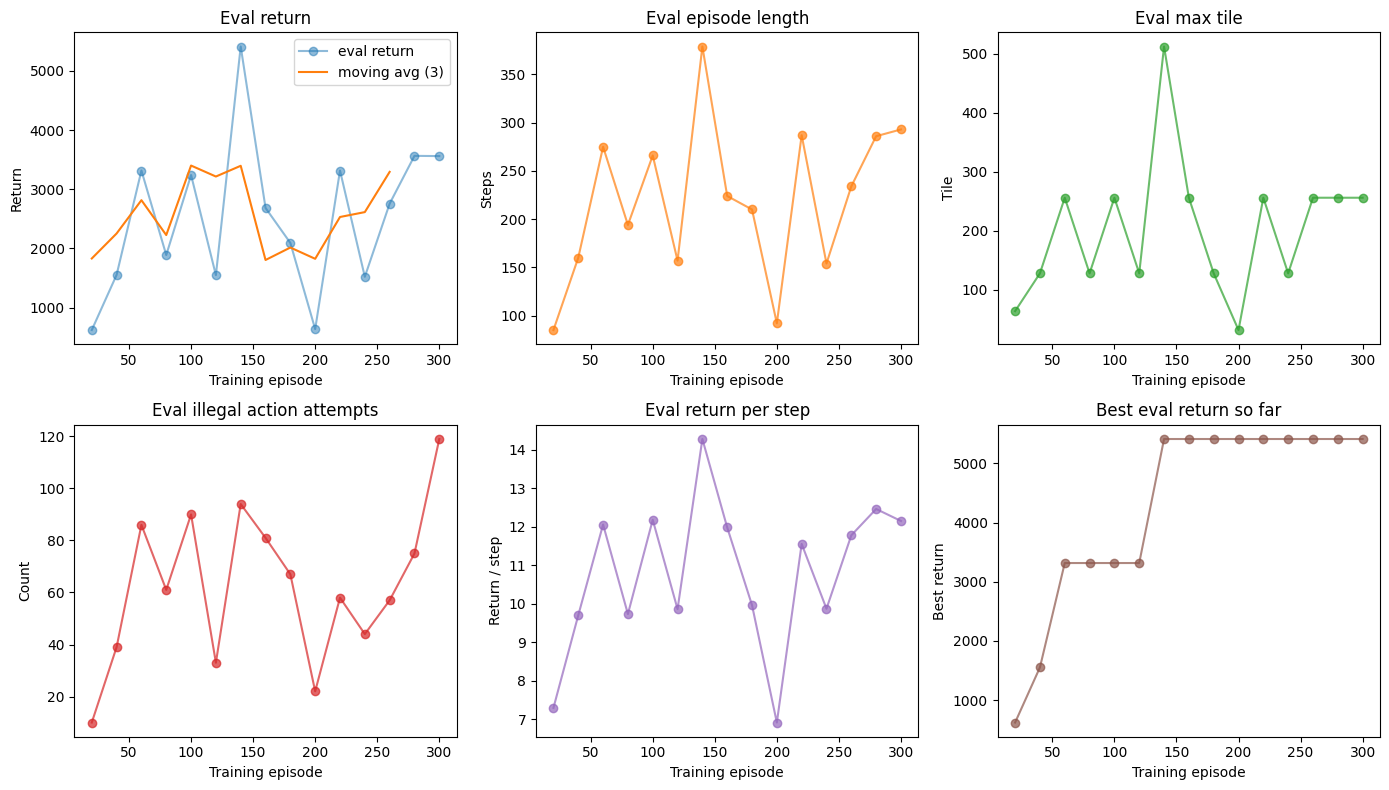

Plotted 15 evaluation checkpoints across 6 panels.
Detailed step rollouts are available in TRAINING_INSIGHTS['eval_rollout'].


In [31]:
import matplotlib.pyplot as plt

def moving_average(x, w=3):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w) / w, mode="valid")

if len(TRAINING_INSIGHTS["eval_episode"]) == 0:
    print("No training insights found yet.")
    print("Run the training cell first, then run this plotting cell again.")
else:
    episodes = np.asarray(TRAINING_INSIGHTS["eval_episode"], dtype=np.int64)
    eval_return = np.asarray(TRAINING_INSIGHTS["eval_return"], dtype=np.float32)
    eval_length = np.asarray(TRAINING_INSIGHTS["eval_length"], dtype=np.int64)
    eval_max_tile = np.asarray(TRAINING_INSIGHTS["eval_max_tile"], dtype=np.int64)
    eval_illegal = np.asarray(TRAINING_INSIGHTS["eval_illegal_action_attempts"], dtype=np.int64)

    safe_len = np.maximum(eval_length, 1)
    return_per_step = eval_return / safe_len
    best_so_far = np.maximum.accumulate(eval_return)

    plt.figure(figsize=(14, 8))

    # 1) Eval return with a short moving average trend line
    plt.subplot(2, 3, 1)
    plt.plot(episodes, eval_return, marker="o", alpha=0.5, label="eval return")
    ma = moving_average(eval_return, 3)
    ma_ep = episodes[: len(ma)]
    plt.plot(ma_ep, ma, label="moving avg (3)")
    plt.title("Eval return")
    plt.xlabel("Training episode")
    plt.ylabel("Return")
    plt.legend()

    # 2) Eval episode length
    plt.subplot(2, 3, 2)
    plt.plot(episodes, eval_length, marker="o", alpha=0.7, color="tab:orange")
    plt.title("Eval episode length")
    plt.xlabel("Training episode")
    plt.ylabel("Steps")

    # 3) Eval max tile
    plt.subplot(2, 3, 3)
    plt.plot(episodes, eval_max_tile, marker="o", alpha=0.7, color="tab:green")
    plt.title("Eval max tile")
    plt.xlabel("Training episode")
    plt.ylabel("Tile")

    # 4) Eval illegal action attempts
    plt.subplot(2, 3, 4)
    plt.plot(episodes, eval_illegal, marker="o", alpha=0.7, color="tab:red")
    plt.title("Eval illegal action attempts")
    plt.xlabel("Training episode")
    plt.ylabel("Count")

    # 5) Return per step
    plt.subplot(2, 3, 5)
    plt.plot(episodes, return_per_step, marker="o", alpha=0.7, color="tab:purple")
    plt.title("Eval return per step")
    plt.xlabel("Training episode")
    plt.ylabel("Return / step")

    # 6) Best return so far
    plt.subplot(2, 3, 6)
    plt.plot(episodes, best_so_far, marker="o", alpha=0.7, color="tab:brown")
    plt.title("Best eval return so far")
    plt.xlabel("Training episode")
    plt.ylabel("Best return")

    plt.tight_layout()
    plt.show()

    print(f"Plotted {len(episodes)} evaluation checkpoints across 6 panels.")
    if TRAINING_INSIGHTS["eval_rollout"]:
        print("Detailed step rollouts are available in TRAINING_INSIGHTS['eval_rollout'].")

In [32]:
eval_data = evaluate_policy(args, q_policy, num_actions, device)
save_artifacts(args, q_net, target_net, obs_dim, num_actions, eval_data)

print("\nModel info:")
print("  obs_dim:", obs_dim)
print("  num_actions:", num_actions)
print("  num_quantiles:", q_net.num_quantiles)

print("Evaluation summary:")
for key, value in eval_data["summary"].items():
    print(f"  {key}: {value}")

Results over 100 seeds:
  Average return:           2171.6 +/- 1093.4
  Average episode length:   197.8
  Average max tile:         176.3
  Average illegal attempts: 47.8
  Total illegal attempts:   4776
Skipping save: pass output_dir to persist checkpoint and evaluation files.

Model info:
  obs_dim: 16
  num_actions: 4
  num_quantiles: 51
Evaluation summary:
  avg_return: 2171.6
  std_return: 1093.3685929273806
  min_return: 332.0
  max_return: 5468.0
  avg_length: 197.76
  avg_max_tile: 176.32
  avg_illegal_action_attempts: 47.76
  total_illegal_action_attempts: 4776
